# API Features

This notebook demonstrates the new API features added in epimodels v0.5.3:

- `to_dataframe()` - Export results to pandas DataFrame
- `to_dict()` - Get a copy of simulation traces
- `summary()` - Get epidemic summary statistics
- `copy()` - Create a copy of the model
- `reset()` - Clear simulation results
- `R0` property - Basic reproduction number
- Parameter validation

In [1]:
from epimodels.continuous import SIR, SIS, SEIR, SIRS
from epimodels.discrete import SIR as DiscreteSIR
from epimodels import ValidationError
import matplotlib.pyplot as plt

## Basic Reproduction Number (R0)

The R0 property returns the basic reproduction number for the model. It's calculated from the model parameters after running a simulation.

In [2]:
model = SIR()

# R0 is None before running the model
print(f"R0 before simulation: {model.R0}")

# Run the model
model([1000, 1, 0], [0, 100], 1001, {'beta': 0.3, 'gamma': 0.1})

# Now R0 is available (beta/gamma = 3.0)
print(f"R0 after simulation: {model.R0}")

R0 before simulation: None
R0 after simulation: 2.9999999999999996


### R0 for different models

The R0 property is available for SIR, SIS, SEIR, and SIRS models.

In [3]:
# SIS model
sis = SIS()
sis([1000, 1], [0, 50], 1001, {'beta': 0.5, 'gamma': 0.25})
print(f"SIS R0: {sis.R0}")

# SEIR model
seir = SEIR()
seir([1000, 0, 1, 0], [0, 50], 1001, {'beta': 0.4, 'gamma': 0.2, 'epsilon': 0.1})
print(f"SEIR R0: {seir.R0}")

# SIRS model
sirs = SIRS()
sirs([1000, 1, 0], [0, 50], 1001, {'beta': 0.6, 'gamma': 0.3, 'xi': 0.05})
print(f"SIRS R0: {sirs.R0}")

SIS R0: 2.0
SEIR R0: 2.0
SIRS R0: 2.0


## Summary Statistics

The `summary()` method returns key epidemic statistics from the simulation.

In [4]:
model = SIR()
model([1000, 1, 0], [0, 100], 1001, {'beta': 0.3, 'gamma': 0.1})

stats = model.summary()
print("Epidemic Summary:")
for key, value in stats.items():
    print(f"  {key}: {value:.2f}" if isinstance(value, float) else f"  {key}: {value}")

Epidemic Summary:
  model: SIR
  t_start: 0.00
  t_end: 100.00
  peak_I: 298.70
  peak_time: 37.05
  final_S: 60.75
  final_R: 936.14
  attack_rate: 0.94


### Understanding the statistics

- **peak_I**: Maximum number of infectious individuals
- **peak_time**: Time at which peak I occurs
- **final_S**: Final susceptible count
- **final_R**: Final removed (recovered) count
- **attack_rate**: Proportion of population that was infected

## Export to DataFrame

The `to_dataframe()` method exports simulation results to a pandas DataFrame for easy analysis.

In [5]:
model = SIR()
model([1000, 1, 0], [0, 50], 1001, {'beta': 0.3, 'gamma': 0.1})

df = model.to_dataframe()
print(f"DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

DataFrame shape: (10, 4)
Columns: ['S', 'I', 'R', 'time']


,S,I,R,time
0,1000.000000,1.000000,0.000000,0.000000
1,999.995758,1.002827,0.001416,0.014135
2,999.952671,1.031536,0.015792,0.155485
3,999.447946,1.367801,0.184253,1.568989
4,996.610788,3.256427,1.132785,5.924102


In [6]:
# DataFrame allows easy analysis
print(f"Max I: {df['I'].max():.1f}")
print(f"Time of peak: {df.loc[df['I'].idxmax(), 'time']:.1f}")
print(f"Final R: {df['R'].iloc[-1]:.1f}")

Max I: 298.7
Time of peak: 37.0
Final R: 667.8


## Copy and Reset

### Copy a model

In [7]:
model = SIR()
model([1000, 1, 0], [0, 50], 1001, {'beta': 0.3, 'gamma': 0.1})

# Copy without results
new_model = model.copy(include_traces=False)
print(f"Original traces: {len(model.traces)}")
print(f"Copy traces: {len(new_model.traces)}")

# Copy with results
full_copy = model.copy(include_traces=True)
print(f"Full copy traces: {len(full_copy.traces)}")

Original traces: 4
Copy traces: 0
Full copy traces: 4


### Reset a model

In [8]:
model = SIR()
model([1000, 1, 0], [0, 50], 1001, {'beta': 0.3, 'gamma': 0.1})
print(f"Before reset: {len(model.traces)} traces")

model.reset()
print(f"After reset: {len(model.traces)} traces")

# Can run again with different parameters
model([500, 5, 0], [0, 30], 505, {'beta': 0.4, 'gamma': 0.2})
print(f"After re-run: {len(model.traces)} traces")

Before reset: 4 traces
After reset: 0 traces
After re-run: 4 traces


## Parameter Validation

Models now validate parameters and initial conditions by default.

In [9]:
model = SIR()

# Missing parameter
try:
    model([1000, 1, 0], [0, 50], 1001, {'beta': 0.3})  # Missing gamma
except ValidationError as e:
    print(f"Validation error: {e}")

Validation error: Missing required parameters: {'gamma'}


In [10]:
# Negative parameter
try:
    model([1000, 1, 0], [0, 50], 1001, {'beta': -0.3, 'gamma': 0.1})
except ValidationError as e:
    print(f"Validation error: {e}")

Validation error: Parameter 'beta' must be non-negative, got -0.3


In [11]:
# Initial conditions exceed population
try:
    model([1000, 100, 0], [0, 50], 1001, {'beta': 0.3, 'gamma': 0.1})
except ValidationError as e:
    print(f"Validation error: {e}")

Validation error: Sum of initial conditions (1100) exceeds total population (1001)


### Disable validation

Validation can be disabled for performance or special cases.

In [12]:
# Validation disabled - no error raised
model([1000, 1, 0], [0, 50], 1001, {'beta': 0.3, 'gamma': 0.1}, validate=False)
print("No validation error with validate=False")

No validation error with validate=False


## Complete Example

Let's put it all together with a complete example.

Basic reproduction number (R0): 3.00

Epidemic Summary:
  Peak infected: 286 at day 31
  Attack rate: 94.1%


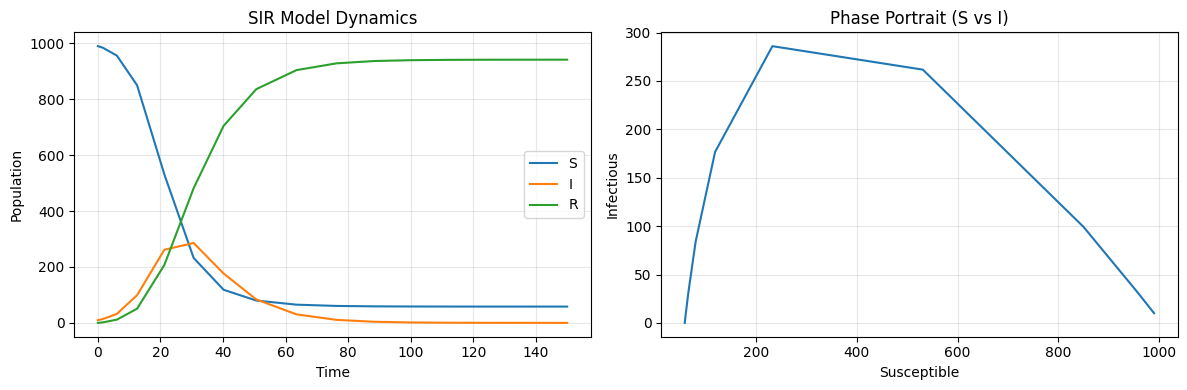

In [13]:
# Create and run model
model = SIR()
model([990, 10, 0], [0, 150], 1000, {'beta': 0.3, 'gamma': 0.1})

# Get R0
print(f"Basic reproduction number (R0): {model.R0:.2f}")

# Get summary
stats = model.summary()
print(f"\nEpidemic Summary:")
print(f"  Peak infected: {stats['peak_I']:.0f} at day {stats['peak_time']:.0f}")
print(f"  Attack rate: {stats['attack_rate']*100:.1f}%")

# Export to DataFrame
df = model.to_dataframe()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Time series
df.plot(x='time', y=['S', 'I', 'R'], ax=axes[0])
axes[0].set_title('SIR Model Dynamics')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Population')
axes[0].grid(True, alpha=0.3)

# Phase portrait
axes[1].plot(df['S'], df['I'])
axes[1].set_title('Phase Portrait (S vs I)')
axes[1].set_xlabel('Susceptible')
axes[1].set_ylabel('Infectious')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()